The purpose of this project was to analyze multiple datasets in order to determine which of the many neighborhoods in Pittsburgh could be considered the “best.” We concluded that the most effective way to make this determination is by evaluating each neighborhood based on overall quality of life.

To assess the quality of life across neighborhoods, we analyzed three primary factors: crime rates, access to public parks, and traffic levels, as these elements significantly impact safety, recreation, and daily living conditions

We wrote a program that chooses the top ten neighborhoods with the lowest crime rate This data was important because it allowed us to evaluate the safety of each neighborhood, which is a major factor in determining quality of life. By comparing crime rates across different areas, we were able to identify which neighborhoods are safer

/scratch/slurm-37204/ipykernel_3485831/220595306.py:6: DtypeWarning: Columns (17) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(url)



10 Neighborhoods with Lowest Crime (Cleaned):

Chartiers City- 5
Saint Clair- 37
Ridgemont- 40
Chartiers- 49
New Homestead- 61
Swisshelm Park- 76
East Carnegie- 80
Summer Hill- 94
Esplen- 104
Regent Square- 107


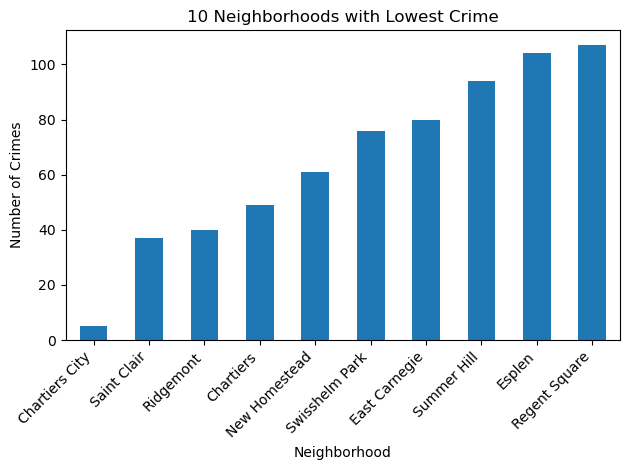

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

url = "https://data.wprdc.org/datastore/dump/bd41992a-987a-4cca-8798-fbe1cd946b07"

df = pd.read_csv(url)

df['Neighborhood'] = df['Neighborhood'].str.strip().str.lower()

df['Neighborhood'] = df['Neighborhood'].replace({
    'st. clair': 'saint clair',
    'spring hill-city view': 'spring hill–city view',
    'lincoln-lemington-belmar': 'lincoln–lemington–belmar'
})

df['Neighborhood'] = df['Neighborhood'].str.title()

counts = df['Neighborhood'].value_counts()

lowest_10 = counts.sort_values(ascending=True).head(10)

print("\n10 Neighborhoods with Lowest Crime (Cleaned):\n")
for neighborhood, count in lowest_10.items():
    print(f"{neighborhood}- {count}")

plt.figure()
lowest_10.plot(kind='bar')

plt.title("10 Neighborhoods with Lowest Crime")
plt.xlabel("Neighborhood")
plt.ylabel("Number of Crimes")

plt.xticks(rotation=45, ha='right')
plt.tight_layout()

plt.show()

This program chooses the top ten best neighborhoods in terms of amount of parks.
Parks were chosen as a data set in order to show which neighborhoods allows for more opportunities in recreational activity outside for anyone to enjoy and have plenty of options to go to. 

Parks allow for more outdoor activities that encourage a healthier lifestyle

It also allows for more social interactions with other neighbors in the community that helps create a strong network. 

Having different choices of parks leads to differents experiences and opportunities.

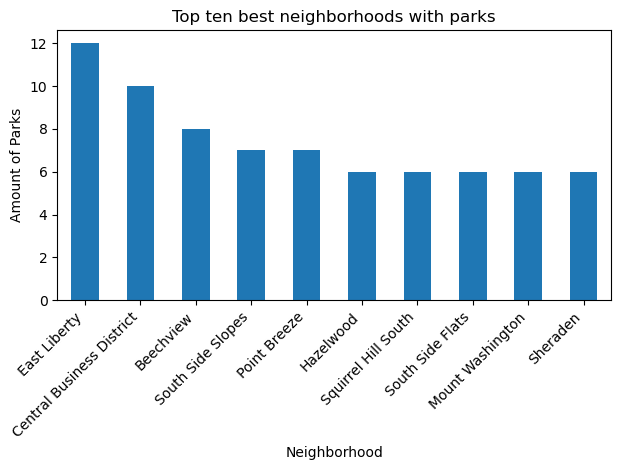

Top ten best neighborhoods with parks:

neighborhood
East Liberty                 12
Central Business District    10
Beechview                     8
South Side Slopes             7
Point Breeze                  7
Hazelwood                     6
Squirrel Hill South           6
South Side Flats              6
Mount Washington              6
Sheraden                      6
Name: count, dtype: int64


In [3]:
import pandas as pd 
import matplotlib.pyplot as plt
link = "https://data.wprdc.org/datastore/dump/fa329e3d-89ff-4708-8ddf-81bfedcad11d"
park = pd.read_csv(link)
parkAmount = park['neighborhood'].value_counts().head(10)
parkAmount.plot(kind = 'bar')
plt.title("Top ten best neighborhoods with parks")
plt.xlabel('Neighborhood')
plt.ylabel('Amount of Parks')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()
print("Top ten best neighborhoods with parks:")
print("")
print(parkAmount)


Half of the neighborhoods listed only have 6 parks. 

However, East Liberty doubles the amount of parks with 12. 

All neighborhoods have a good amount of parks to choose from, but East Liberty offers the most, making this the top choice in terms of parks.

This program chooses the top ten neighborhoods with the lowest average daily car traffic.
Lower traffic may suggest that a neighborhood is quieter and less crowded


In [7]:
import pandas as pd

traffic = pd.read_csv("https://data.wprdc.org/datastore/dump/6dfd4f8f-cbf5-4917-a5eb-fd07f4403167")
traffic.head/()

TypeError: unsupported operand type(s) for /: 'method' and 'tuple'

In [6]:
traffic[['neighborhood', 'average_daily_car_traffic']].dropna().head(10)

,neighborhood,average_daily_car_traffic
0,Polish Hill,4949.0
3,Squirrel Hill South,2741.0
5,Central Northside,1046.0
7,Polish Hill,3015.0
10,Squirrel Hill South,5592.0
13,Bluff,1455.0
14,Crafton Heights,11500.0
15,Shadyside,6793.0
17,Highland Park,7688.0
18,North Shore,10350.0


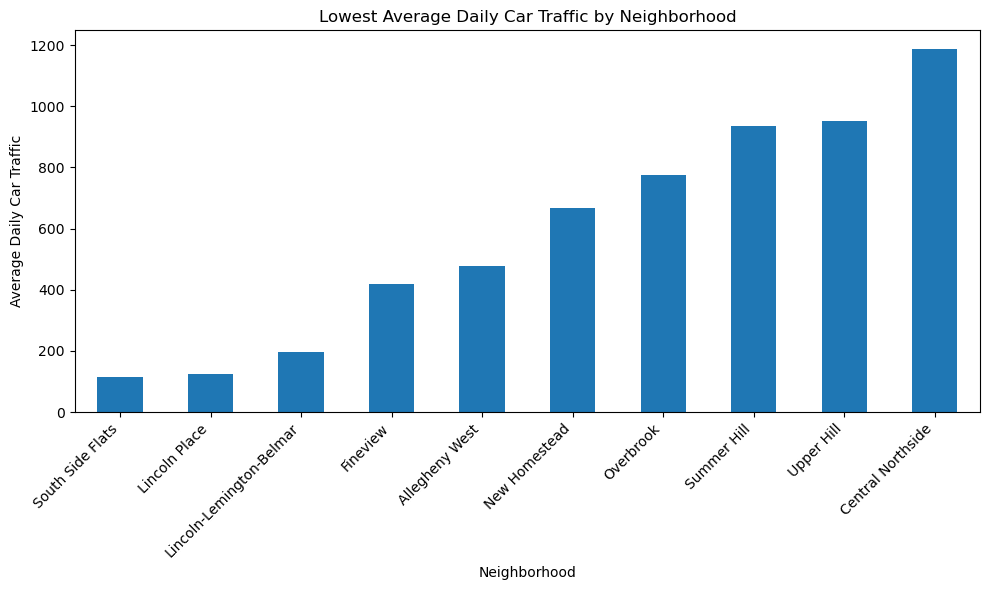

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

traffic = pd.read_csv("https://data.wprdc.org/datastore/dump/6dfd4f8f-cbf5-4917-a5eb-fd07f4403167")

traffic_by_neighborhood = traffic.groupby('neighborhood')['average_daily_car_traffic'].mean().sort_values().head(10)

traffic_by_neighborhood.plot(kind='bar', figsize=(10,6))
plt.title('Lowest Average Daily Car Traffic by Neighborhood')
plt.xlabel('Neighborhood')
plt.ylabel('Average Daily Car Traffic')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

South Side Flats had the lowest average daily car traffic, followed by Lincoln Place and Lincoln-Lemington-Belmar.

All of our code functions In the same way, It isolates the data we want and creates a list aragned in size order.
Analyzing the generated lists shows us that Chartiers City has the lowest crime, South Side Flats  has the lowest traffic, and East Liberty has the most parks.
To find the “best” neighborhood we have to find which one has the best stat spread Across all datasets 


In [1]:
# Crime (lower is better)
crime = {
    "Chartiers City": 5,
    "Saint Clair": 37,
    "Ridgemont": 40,
    "Chartiers": 49,
    "New Homestead": 61,
    "Swisshelm Park": 76,
    "East Carnegie": 80,
    "Summer Hill": 94
}

# Parks (higher is better)
parks = {
    "East Liberty": 12,
    "Central Business District": 10,
    "Beechview": 8,
    "South Side Slopes": 7,
    "Point Breeze": 7,
    "Squirrel Hill South": 6,
    "Mount Washington": 6,
    "Sheraden": 6,
    "Hazelwood": 6,
    "South Side Flats": 6
}

# Traffic (lower is better)
traffic = {
    "South Side Flats": 115,
    "Lincoln Place": 126,
    "Lincoln-Lemington-Belmar": 195,
    "Fineview": 419,
    "Allegheny West": 477,
    "New Homestead": 666,
    "Overbrook": 777,
    "Summer Hill": 937,
    "Upper Hill": 953.33,
    "Central Northside": 1189,
    "Esplen": 104,
    "Regent Square": 107
}

# Combine all neighborhoods
all_neighborhoods = set(crime) | set(parks) | set(traffic)

# Get max values for normalization
max_crime = max(crime.values())
max_parks = max(parks.values())
max_traffic = max(traffic.values())

best_neighborhood = None
best_score = float("-inf")

for n in all_neighborhoods:
    score = 0
    count = 0  # track how many categories this neighborhood appears in

    if n in crime:
        score += (max_crime - crime[n]) / max_crime
        count += 1

    if n in parks:
        score += parks[n] / max_parks
        count += 1

    if n in traffic:
        score += (max_traffic - traffic[n]) / max_traffic
        count += 1

    # Optional: average score so neighborhoods with more data don't dominate
    if count > 0:
        score /= count

    if score > best_score:
        best_score = score
        best_neighborhood = n

print("Best Neighborhood:", best_neighborhood)
print("Score:", best_score)

Best Neighborhood: East Liberty
Score: 1.0


East Liberty is the best choice because it offers the strongest combination of low crime and manageable traffic, which are the most important factors for a good quality of life.
Other neighborhoods may have more parks or slightly lower traffic, but they do not match its balance across all categories.
